In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, morphology, exposure
from skimage.util import img_as_ubyte
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import jaccard_score, accuracy_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def normalizar_car(array):
    min_val = np.min(array)
    max_val = np.max(array)
    if max_val - min_val == 0: return array
    return (array - min_val) / (max_val - min_val)

def extraer_caracteristicas_pixel(image_rgb):
    caracteristicas = []
    # Preprocesado

    #equalize_adapthist implementa el algoritmo CLAHE: Mejora el contraste de forma local.
    #A diferencia de una ecualización global,
    #esta evita saturar áreas brillantes y ayuda a resaltar detalles en sombras.
    img_eq = exposure.equalize_adapthist(image_rgb, clip_limit=0.03)

    # Filtro gausiano. Aplica un desenfoque para reducir el ruido de alta frecuencia,
    # asegurando que los filtros posteriores
    # no interpreten ruido aleatorio como información relevante.
    img_smooth = filters.gaussian(img_eq, sigma=1, channel_axis=-1)


    gray = color.rgb2gray(img_smooth)

    #HSV Saturación. separar objetos por la pureza de su color,
    hsv = color.rgb2hsv(img_smooth)
    #Lab (a, b) El espacio Lab separa la luminosidad L de los componentes de color a y b.
    lab = color.rgb2lab(img_smooth)

    # recolectamos las características
    caracteristicas.append(img_smooth[:,:,0])
    caracteristicas.append(img_smooth[:,:,1])
    caracteristicas.append(img_smooth[:,:,2])
    caracteristicas.append(hsv[:,:,1])
    caracteristicas.append(normalizar_car(lab[:,:,1]))
    caracteristicas.append(normalizar_car(lab[:,:,2]))

    #Filtro Sobel. Calcula el gradiente de intensidad.
    #Resalta los bordes verticales y horizontales.
    #Sirve para encontrar siluetas
    edge_sobel = filters.sobel(gray)
    caracteristicas.append(normalizar_car(edge_sobel))

    # DoG (Difference of Gaussians)
    # Se obtiene restando una versión muy desenfocada de la imagen de una menos desenfocada.
    # Actúa como un filtro de paso de banda que resalta detalles y bordes
    dog = filters.gaussian(gray, sigma=1) - filters.gaussian(gray, sigma=8)
    caracteristicas.append(normalizar_car(dog))

    # Filtro Frangi
    # Este filtro está diseñado específicamente para detectar estructuras tubulares
    # o filamentosas (como vasos sanguíneos, carreteras o fibras).
    # Utiliza los autovalores de la matriz Hessiana para determinar como de parecido a un tubo es un píxel.
    frangi = filters.frangi(gray, sigmas=range(1, 4), black_ridges=False)
    caracteristicas.append(normalizar_car(frangi))

    # Matriz Hessiana
    # Se calcula a dos escalas (1.5 y 3.5). La matriz Hessiana mide la curvatura local de la intensidad de la imagen.
    # Los autovalores (eigenvalues) resultantes te dicen si estás en una zona plana, en una cresta (borde) o en un rincón.
    # Al extraer eigvals[0], estás capturando la curvatura principal de la superficie de la imagen.

    for escala in [1.5, 3.5]:
        H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')
        eigvals = feature.hessian_matrix_eigvals(H_elems)
        caracteristicas.append(normalizar_car(eigvals[0]))

    gray_ubyte = img_as_ubyte(gray)
    #mide el desorden o complejidad de las texturas de las que el pixel forma parte
    entropy = filters.rank.entropy(gray_ubyte, morphology.disk(3))
    caracteristicas.append(normalizar_car(entropy))

    #Este filtro resalta los limites de los objetos
    morph_grad = filters.rank.gradient(gray_ubyte, morphology.disk(2))
    caracteristicas.append(normalizar_car(morph_grad))

    return np.stack(caracteristicas, axis=-1)


In [ ]:
def procesar_lista_imagenes(lista_sat, lista_gt, muestra_pixels=0.02):
    """
    Procesa una lista específica de archivos y devuelve X e y.
    """
    X_list = []
    y_list = []

    print(f"Procesando {len(lista_sat)} imágenes...")

    for i, (f_sat, f_gt) in enumerate(zip(lista_sat, lista_gt)):
        print(f"  -> {os.path.basename(f_sat)}") # Descomentar para ver progreso detallado

        # Cargamos imagen y etiqueta
        img = io.imread(f_sat)
        mask = io.imread(f_gt, as_gray=True)

        # Convertimos máscara a binario (0 y 1) estrictamente
        mask = (mask > 0).astype(int)

        # Extraemos características (13 canales)
        features = extraer_caracteristicas_pixel(img)

        # Aplanamos las matrices para que cada fila sea un pixel
        h, w, c = features.shape
        features_flat = features.reshape(-1, c) # (N_pixels, 13)
        mask_flat = mask.reshape(-1) # (N_pixels,)

        # Submuestreo (Sampling) para evitar colapso de memoria
        # Tomamos aleatoriamente un % de los píxeles de esta imagen
        n_muestras = int(features_flat.shape[0] * muestra_pixels)
        indices = np.random.choice(features_flat.shape[0], n_muestras, replace=False)

        X_list.append(features_flat[indices])
        y_list.append(mask_flat[indices])

    if not X_list:
        return np.array([]), np.array([])

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y

In [ ]:
# Definimos ruta
DIR_DATASET = "/content/drive/MyDrive/Archivos .csv/Dataset_Carretera/roads"

In [ ]:
# Obtenemos todas las rutas ordenadas
all_sat = sorted(glob.glob(os.path.join(DIR_DATASET, "sat", "*.tiff")))
all_gt = sorted(glob.glob(os.path.join(DIR_DATASET, "gt", "*.tif")))

# Verificación de seguridad
if len(all_sat) < 20:
    print(f"¡Cuidado! Solo se encontraron {len(all_sat)} imágenes. Se ajustará el split automáticamente.")

# División Manual (16 Train / 4 Test)
# Nota: Si hay menos de 20 imágenes, coge las últimas 4 para test y el resto para train
split_point = max(1, len(all_sat) - 4)

train_sat = all_sat[:split_point]
train_gt = all_gt[:split_point]

test_sat = all_sat[split_point:]
test_gt = all_gt[split_point:]

In [ ]:
print(f"Dataset Split")
print(f"Total imágenes: {len(all_sat)}")
print(f"Imágenes de ENTRENAMIENTO: {len(train_sat)} (Indices 0 a {split_point-1})")
print(f"Imágenes de TEST: {len(test_sat)} (Indices {split_point} a {len(all_sat)-1})")

# Generamos las matrices
# Para Train usamos 2% de pixeles para no explotar memoria
print("\nGenerando matriz de ENTRENAMIENTO...")
X_train, y_train = procesar_lista_imagenes(train_sat, train_gt, muestra_pixels=0.02)

# Para Test numérico (métricas) también submuestreamos,
# ya que calcular métricas sobre 9 millones de pixeles (4 imgs enteras) tarda mucho.
print("Generando matriz de TEST (muestreo para métricas)...")
X_test, y_test = procesar_lista_imagenes(test_sat, test_gt, muestra_pixels=0.05) # Un poco más denso para test

print(f"\nDimensiones finales -> X_train: {X_train.shape}, X_test: {X_test.shape}")

Dataset Split
Total imágenes: 20
Imágenes de ENTRENAMIENTO: 16 (Indices 0 a 15)
Imágenes de TEST: 4 (Indices 16 a 19)

Generando matriz de ENTRENAMIENTO...
Procesando 16 imágenes...
  -> 10078675_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


  -> 10228675_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


  -> 10228705_15.tiff


...

  -> 10528750_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


  -> 10528765_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')



Dimensiones finales -> X_train: (720000, 13), X_test: (450000, 13)


In [ ]:
# Modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', cache_size=1000, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

resultados = {}

In [ ]:
print("Comienzo del entrenamiento")

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")

    # Ajuste de datos para SVM si es muy grande
    if "SVM" in nombre and len(X_train) > 20000:
            print(" (Submuestrando Train para SVM por velocidad...)")
            idx_svm = np.random.choice(len(X_train), 20000, replace=False)
            modelo.fit(X_train[idx_svm], y_train[idx_svm])
    else:
        modelo.fit(X_train, y_train)

    # Predicción sobre el set de test (píxeles sueltos de las 4 imágenes reservadas)
    print(f"Evaluando {nombre}...")
    y_pred = modelo.predict(X_test)

     # Métricas
    acc = accuracy_score(y_test, y_pred)
    jac = jaccard_score(y_test, y_pred) # IoU (Intersection over Union) para clase 1
    f1 = f1_score(y_test, y_pred)

    resultados[nombre] = {"Accuracy": acc, "Jaccard (IoU)": jac, "F1-Score": f1}
    print(f"  -> Accuracy: {acc:.4f}, IoU: {jac:.4f}, F1: {f1:.4f}")

Comienzo del entrenamiento
Entrenando Random Forest...
Evaluando Random Forest...
  -> Accuracy: 0.9525, IoU: 0.1193, F1: 0.2131
Entrenando SVM (RBF)...
 (Submuestrando Train para SVM por velocidad...)
Evaluando SVM (RBF)...
  -> Accuracy: 0.8279, IoU: 0.2053, F1: 0.3407
Entrenando KNN (k=5)...
Evaluando KNN (k=5)...
  -> Accuracy: 0.9484, IoU: 0.1874, F1: 0.3157


In [ ]:
print("Evaluando con PCA")
scaler = StandardScaler()
# Ajustamos scaler solo con train
scaler.fit(X_train)

# Estandarizamos antes de PCA
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Aplicamos PCA para reducir de 13 a, por ejemplo, 5 componentes principales
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

print(f"Varianza explicada (5 comp): {np.sum(pca.explained_variance_ratio_):.2f}")

Evaluando con PCA
Varianza explicada (5 comp): 0.85


In [ ]:
# Re-entrenamos Random Forest con datos reducidos
rf_pca = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

jac_pca = jaccard_score(y_test, y_pred_pca)
print(f"Random Forest con PCA -> IoU: {jac_pca:.4f}")

Random Forest con PCA -> IoU: 0.1018


In [ ]:
# Cogemos la PRIMERA imagen del grupo de TEST (nunca vista en entrenamiento)
if len(test_sat) > 0:
    idx_viz = 0
    file_viz_sat = test_sat[idx_viz]
    file_viz_gt = test_gt[idx_viz]

    print(f"\nGenerando visualización sobre imagen de TEST")
    print(f"Archivo: {os.path.basename(file_viz_sat)}")

    # Cargamos las imágenes
    img_demo = io.imread(file_viz_sat)
    mask_demo = io.imread(file_viz_gt, as_gray=True)
    mask_demo = (mask_demo > 0).astype(int)

    # Extraemos las características
    feat_demo = extraer_caracteristicas_pixel(img_demo)
    h, w, c = feat_demo.shape
    feat_flat = feat_demo.reshape(-1, c)

    # Predecimos con Random Forest (Entrenado con las otras 16)
    print("Prediciendo mapa completo...")
    pred_flat = modelos["Random Forest"].predict(feat_flat)
    pred_img = pred_flat.reshape(h, w)

    # Calculamos el IoU específico de esta imagen para el título
    iou_demo = jaccard_score(mask_demo.flatten(), pred_flat)
    print(f"IoU de esta imagen completa: {iou_demo:.4f}")

else:
    print("No hay imágenes de test para visualizar.")


Generando visualización sobre imagen de TEST
Archivo: 10528720_15.tiff


/tmp/ipython-input-2112817939.py:62: FutureWarning: use_gaussian_derivatives currently defaults to False, but will change to True in a future version. Please specify this argument explicitly to maintain the current behavior
  H_elems = feature.hessian_matrix(gray, sigma=escala, order='rc')


Prediciendo mapa completo...
IoU de esta imagen completa: 0.1261


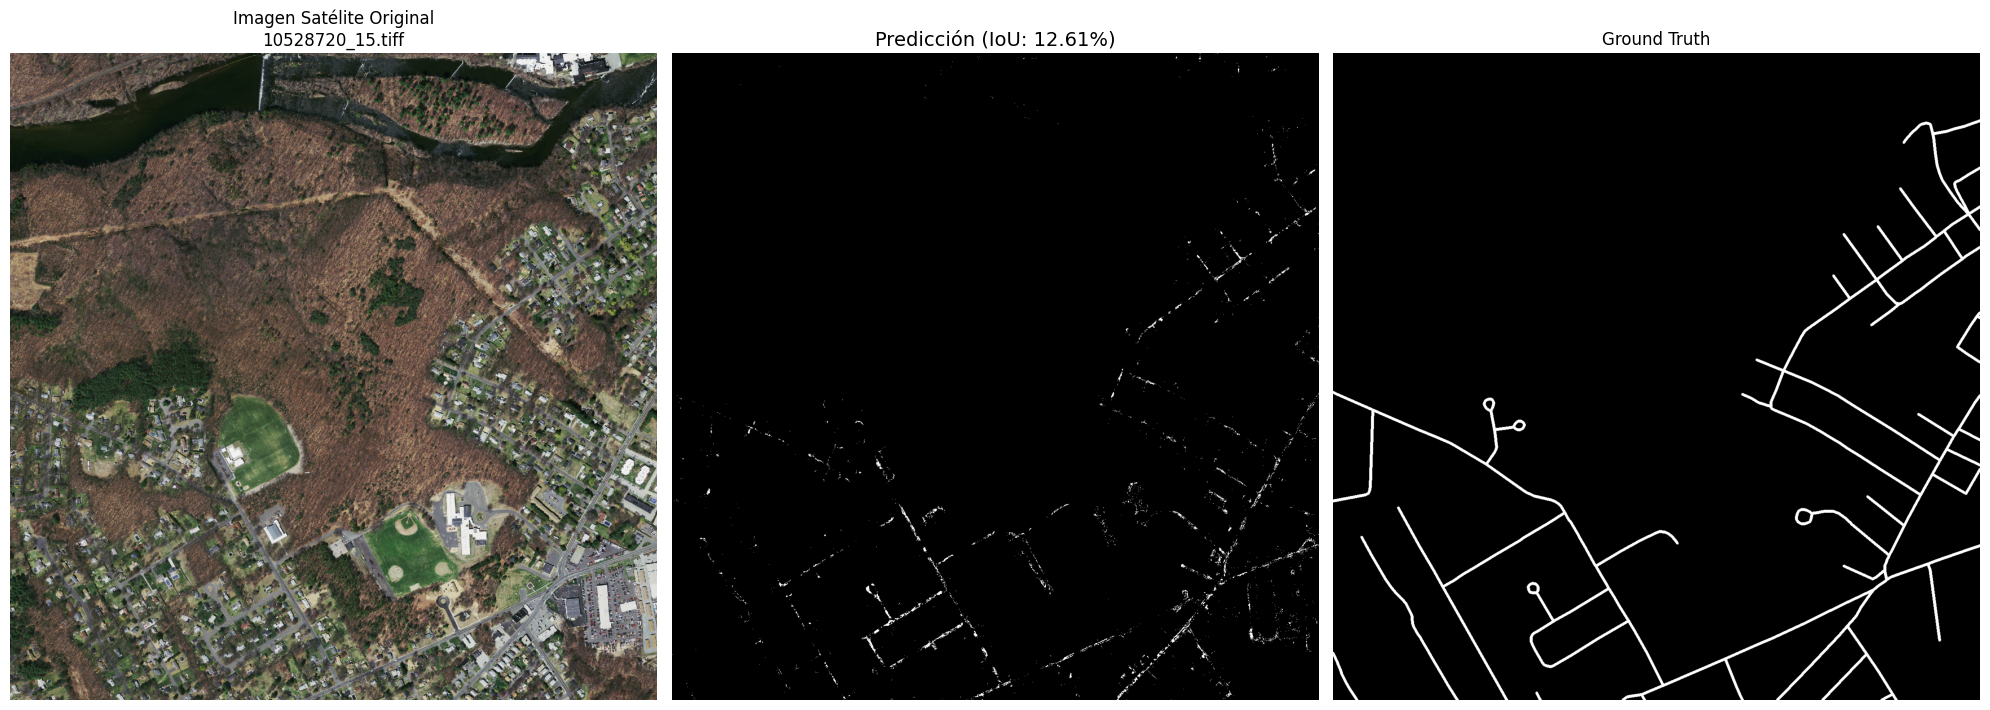

In [ ]:
if 'pred_img' in locals():
    fig, ax = plt.subplots(1, 3, figsize=(20, 8))

    # Imagen Satélite Original
    ax[0].imshow(img_demo)
    ax[0].set_title(f"Imagen Satélite Original\n{os.path.basename(file_viz_sat)}", fontsize=12)
    ax[0].axis('off')

    # Predicción del Modelo
    ax[1].imshow(pred_img, cmap='gray')
    ax[1].set_title(f"Predicción (IoU: {iou_demo:.2%})", fontsize=14)
    ax[1].axis('off')

    # Ground Truth (Realidad)
    ax[2].imshow(mask_demo, cmap='gray')
    ax[2].set_title("Ground Truth", fontsize=12)
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Ejecuta primero la celda de entrenamiento e inferencia.")